In [1]:
import pandas as pd
import seaborn
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

Important note: scores are only compared directly eg french1<->english1 or french1<->baseline_french1... (where 1 is the first generation)
Need to improve and calculate scores st french1<->english2, french1<->baseline_french2... etc

In [2]:
lang_compare = pd.read_csv("metrics.csv", index_col=0)
baseline_compare = pd.read_csv("baseline_compare_metrics.csv", index_col=0)

In [3]:
lang_compare.head() # compare between languages eg french1<->english1, french2<->english2, french3<->english3 ... 
                    # and between baselines eg baseline_french1<->baseline_english1 ...

,Model,Question,Cosine,Rouge,fBaseline,Language1-Language2
0,OLMo-7B-Instruct-hf,Question 1,0.8347,0.0736,False,NL-FR
1,OLMo-7B-Instruct-hf,Question 1,0.8748,0.0826,True,NL-FR
2,OLMo-7B-Instruct-hf,Question 1,0.8455,0.0500,False,FR-EN
3,OLMo-7B-Instruct-hf,Question 1,0.9071,0.0423,True,FR-EN
4,OLMo-7B-Instruct-hf,Question 1,0.8546,0.0480,False,EN-NL


In [4]:
baseline_compare.head() # compare specific language and its baseline eg french1<->baseline_french1, french2<->baseline_french2 ...

,Model,Question,Language,Cosine,Rouge
0,OLMo-7B-Instruct-hf,Question 1,NL,0.8460,0.1946
1,OLMo-7B-Instruct-hf,Question 1,NL,0.8003,0.2025
2,OLMo-7B-Instruct-hf,Question 1,NL,0.9297,0.2392
3,OLMo-7B-Instruct-hf,Question 1,EN,0.9535,0.2596
4,OLMo-7B-Instruct-hf,Question 1,EN,0.9051,0.1924


In [5]:
lang_compare.drop("Question", axis=1).groupby(["Model","Language1-Language2", "fBaseline"]).agg(['mean', 'std', 'count'])

Cosine                  \
                                                       mean       std count   
Model               Language1-Language2 fBaseline                             
OLMo-7B-Instruct-hf EN-NL               False      0.742242  0.089611    24   
                                        True       0.758879  0.105815    24   
                    FR-EN               False      0.697446  0.128623    24   
                                        True       0.748721  0.113460    24   
                    NL-FR               False      0.657525  0.131356    24   
                                        True       0.704029  0.095554    24   
Qwen3-32B           EN-NL               False      0.810400  0.096146    24   
                                        True       0.849958  0.070204    24   
                    FR-EN               False      0.840100  0.049404    24   
                                        True       0.847413  0.047921    24   
                    NL-FR               False      0.761150  0.097686    24   
                                        True       0.800038  0.070257    24   

                                                      Rouge                  
                                                       mean       std count  
Model               Language1-Language2 fBaseline                            
OLMo-7B-Instruct-hf EN-NL               False      0.069187  0.043120    24  
                                        True       0.057479  0.015797    24  
                    FR-EN               False      0.050242  0.027277    24  
                                        True       0.058388  0.059697    24  
                    NL-FR               False      0.078863  0.024802    24  
                                        True       0.070938  0.016425    24  
Qwen3-32B           EN-NL               False      0.058033  0.016407    24  
                                        True       0.063454  0.027859    24  
                    FR-EN               False      0.044533  0.009997    24  
                                        True       0.053533  0.022345    24  
                    NL-FR               False      0.060058  0.021484    24  
                                        True       0.056404  0.021716    24

In [6]:
lang_compare.groupby(["Model","Question","Language1-Language2", "fBaseline"]).agg(['mean', 'std', 'count'])

Cosine  \
                                                                  mean   
Model               Question   Language1-Language2 fBaseline             
OLMo-7B-Instruct-hf Question 1 EN-NL               False      0.874100   
                                                   True       0.928400   
                               FR-EN               False      0.869467   
                                                   True       0.901033   
                               NL-FR               False      0.840033   
...                                                                ...   
Qwen3-32B           Question 8 EN-NL               True       0.862400   
                               FR-EN               False      0.860633   
                                                   True       0.791467   
                               NL-FR               False      0.852700   
                                                   True       0.829833   

                                                                              \
                                                                   std count   
Model               Question   Language1-Language2 fBaseline                   
OLMo-7B-Instruct-hf Question 1 EN-NL               False      0.060937     3   
                                                   True       0.019748     3   
                               FR-EN               False      0.060145     3   
                                                   True       0.026036     3   
                               NL-FR               False      0.076040     3   
...                                                                ...   ...   
Qwen3-32B           Question 8 EN-NL               True       0.025734     3   
                               FR-EN               False      0.032293     3   
                                                   True       0.059560     3   
                               NL-FR               False      0.010247     3   
                                                   True       0.036256     3   

                                                                 Rouge  \
                                                                  mean   
Model               Question   Language1-Language2 fBaseline             
OLMo-7B-Instruct-hf Question 1 EN-NL               False      0.052400   
                                                   True       0.059567   
                               FR-EN               False      0.045067   
                                                   True       0.041567   
                               NL-FR               False      0.095233   
...                                                                ...   
Qwen3-32B           Question 8 EN-NL               True       0.048067   
                               FR-EN               False      0.041733   
                                                   True       0.036567   
                               NL-FR               False      0.058800   
                                                   True       0.059267   

                                                                              
                                                                   std count  
Model               Question   Language1-Language2 fBaseline                  
OLMo-7B-Instruct-hf Question 1 EN-NL               False      0.004173     3  
                                                   True       0.002205     3  
                               FR-EN               False      0.012268     3  
                                                   True       0.006830     3  
                               NL-FR               False      0.032087     3  
...                                                                ...   ...  
Qwen3-32B           Question 8 EN-NL               True       0.010401     3  
                               FR-EN               False      0.008503     3  


In [7]:
baseline_compare.drop("Question", axis=1).groupby(["Model", "Language"]).agg(["mean", "count"])

Cosine           Rouge      
                                  mean count      mean count
Model               Language                                
OLMo-7B-Instruct-hf EN        0.832896    24  0.187571    24
                    FR        0.733925    24  0.193971    24
                    NL        0.717950    24  0.188887    24
Qwen3-32B           EN        0.913621    24  0.282929    24
                    FR        0.884904    24  0.256425    24
                    NL        0.799833    24  0.222871    24

In [8]:
baseline_compare.groupby(["Model", "Question", "Language"]).agg(["mean", "count"])

Cosine           Rouge      
                                             mean count      mean count
Model               Question   Language                                
OLMo-7B-Instruct-hf Question 1 EN        0.939567     3  0.223933     3
                               FR        0.867000     3  0.188800     3
                               NL        0.858667     3  0.212100     3
                    Question 2 EN        0.728367     3  0.145033     3
                               FR        0.715333     3  0.184633     3
                               NL        0.728700     3  0.225400     3
                    Question 3 EN        0.823700     3  0.183800     3
                               FR        0.741467     3  0.135333     3
                               NL        0.691033     3  0.079733     3
                    Question 4 EN        0.760233     3  0.156000     3
                               FR        0.660333     3  0.163667     3
                               NL        0.722367     3  0.180000     3
                    Question 5 EN        0.908800     3  0.182467     3
                               FR        0.702200     3  0.184933     3
                               NL        0.616533     3  0.155533     3
                    Question 6 EN        0.709067     3  0.168000     3
                               FR        0.717033     3  0.200267     3
                               NL        0.574733     3  0.192733     3
                    Question 7 EN        0.895767     3  0.227967     3
                               FR        0.890833     3  0.282533     3
                               NL        0.749500     3  0.225533     3
                    Question 8 EN        0.897667     3  0.213367     3
                               FR        0.577200     3  0.211600     3
                               NL        0.802067     3  0.240067     3
Qwen3-32B           Question 1 EN        0.969367     3  0.407667     3
                               FR        0.952567     3  0.356633     3
                               NL        0.928967     3  0.285933     3
                    Question 2 EN        0.955233     3  0.284833     3
                               FR        0.905133     3  0.212200     3
                               NL        0.615567     3  0.155733     3
                    Question 3 EN        0.836800     3  0.176167     3
                               FR        0.784733     3  0.141133     3
                               NL        0.751533     3  0.182267     3
                    Question 4 EN        0.863967     3  0.198833     3
                               FR        0.896933     3  0.197933     3
                               NL        0.671133     3  0.169233     3
                    Question 5 EN        0.928233     3  0.385433     3
                               FR        0.917600     3  0.255100     3
                               NL        0.896067     3  0.325333     3
                    Question 6 EN        0.871733     3  0.244200     3
                               FR        0.842700     3  0.207400     3
                               NL        0.789600     3  0.178333     3
                    Question 7 EN        0.940833     3  0.236833     3
                               FR        0.950767     3  0.385933     3
                               NL        0.838267     3  0.228367     3
                    Question 8 EN        0.942800     3  0.329467     3
                               FR        0.828800     3  0.295067     3
                               NL        0.907533     3  0.257767     3

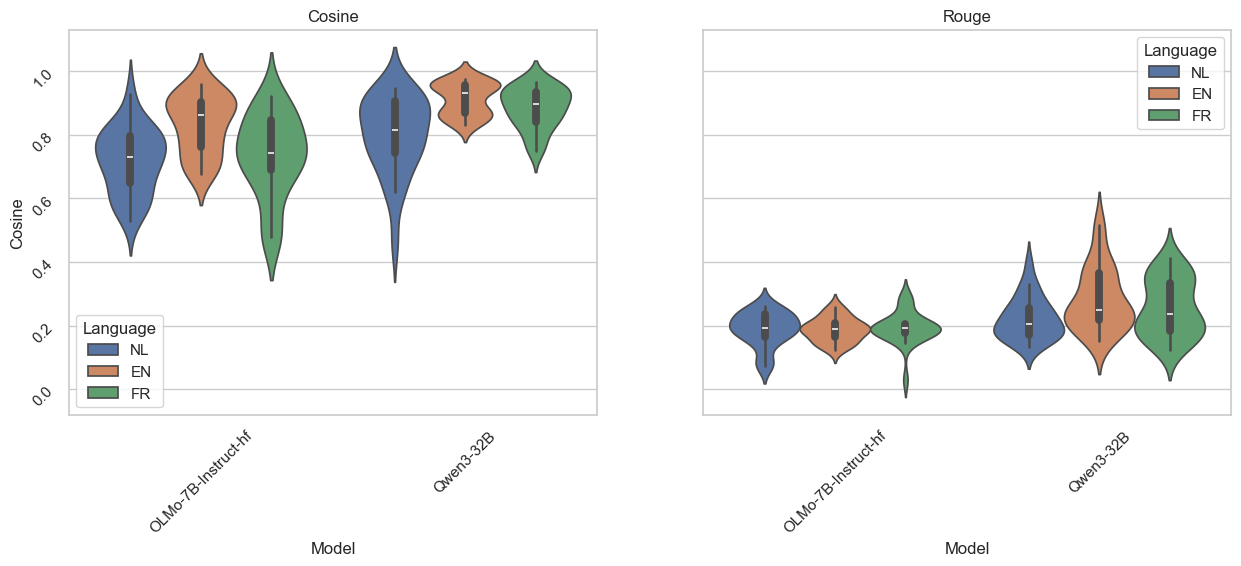

In [9]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]
fig, axs = plt.subplots(ncols=len(ys), figsize=(15,5), sharey=True)

# not between questions, each violin plot has 24 data points
for i in range(len(ys)):
    axs[i].tick_params(labelrotation=45)   
    axs[i].title.set_text(ys[i])
    seaborn.violinplot(x="Model", 
                       y=ys[i], 
                       hue="Language",
                       data=baseline_compare,
                       density_norm='count',
                       ax=axs[i])

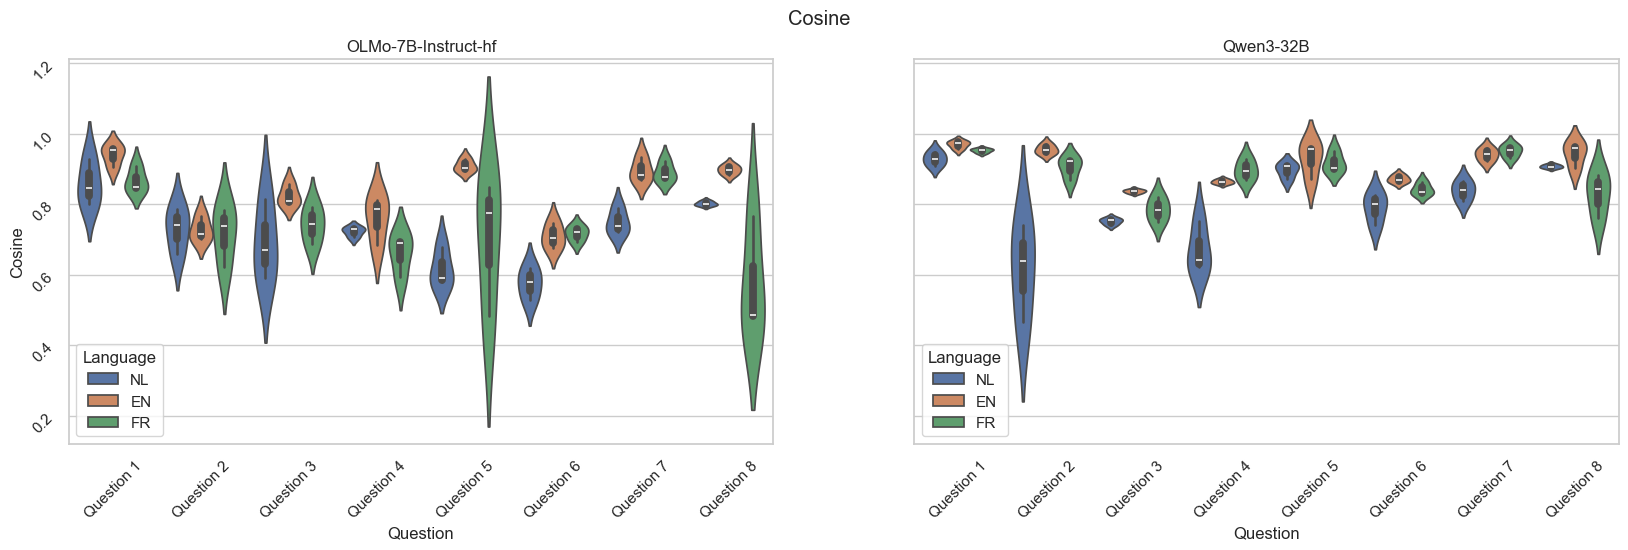

<Figure size 640x480 with 0 Axes>

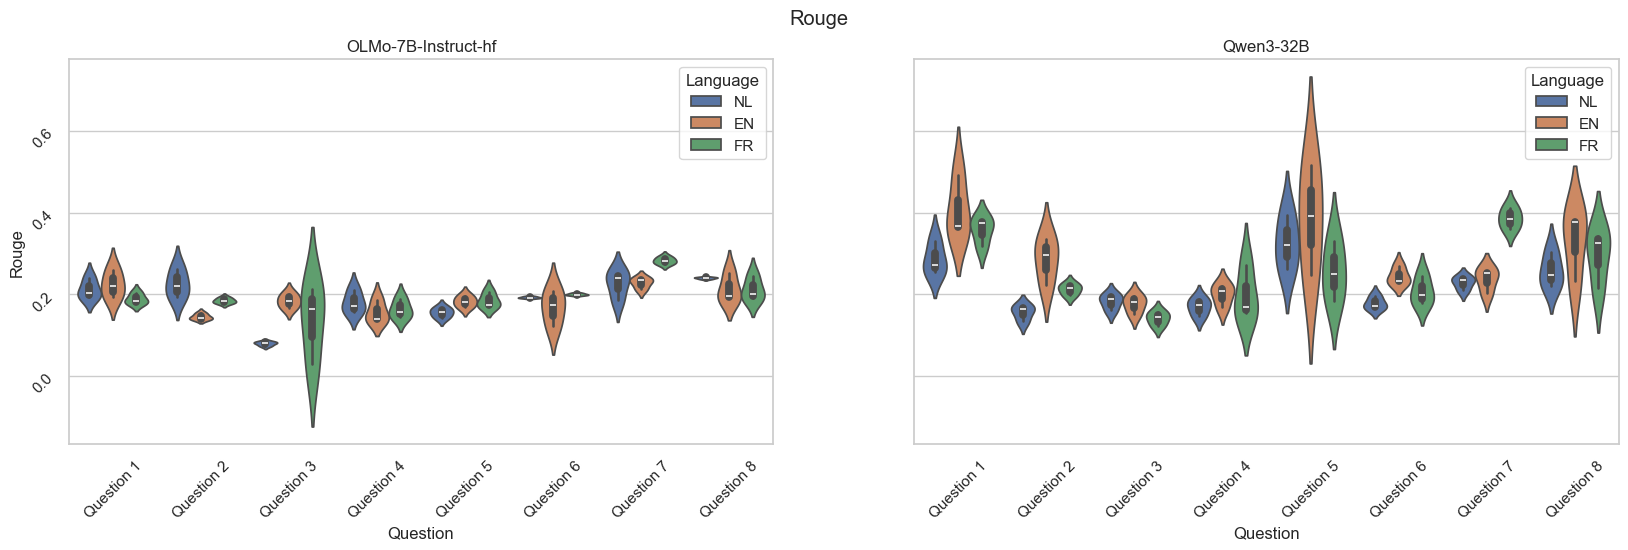

<Figure size 640x480 with 0 Axes>

In [10]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]

# between questions, each violin plot only has 3 data points
for y in ys:
    fig, axs = plt.subplots(ncols=len(baseline_compare["Model"].unique()), figsize=(20,5),  sharey=True)
    fig.suptitle(y)
    i = 0
    for model in baseline_compare["Model"].unique():  
        axs[i].title.set_text(model)
        axs[i].tick_params(labelrotation=45)                    
        seaborn.violinplot(x ="Question", 
                           y=y, 
                           hue="Language",
                           data = baseline_compare[baseline_compare["Model"]==model],
                           density_norm='count',
                           ax=axs[i])
        i+=1
    plt.figure()

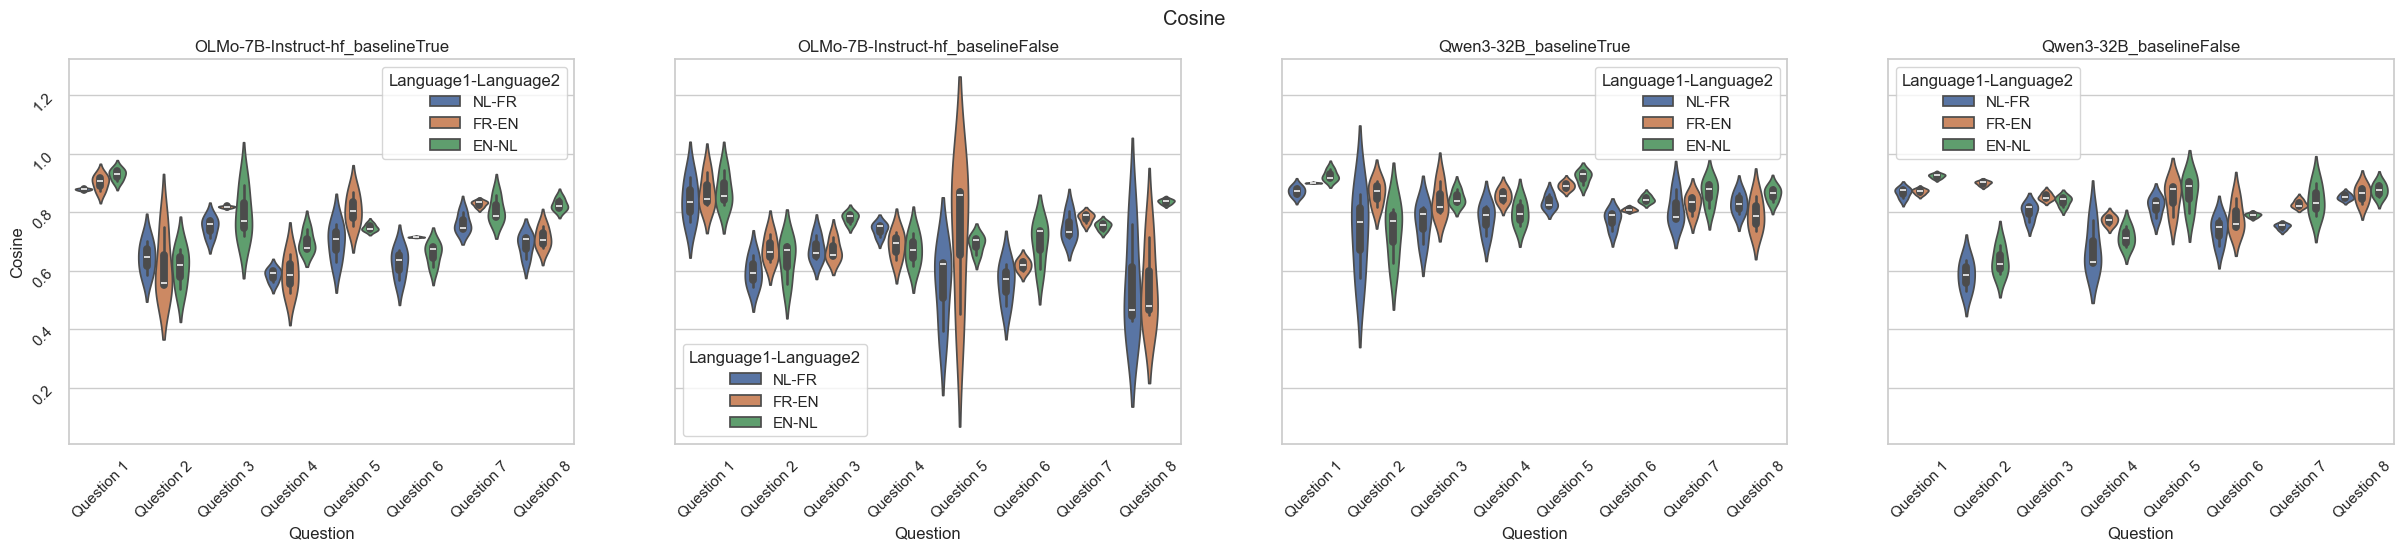

<Figure size 640x480 with 0 Axes>

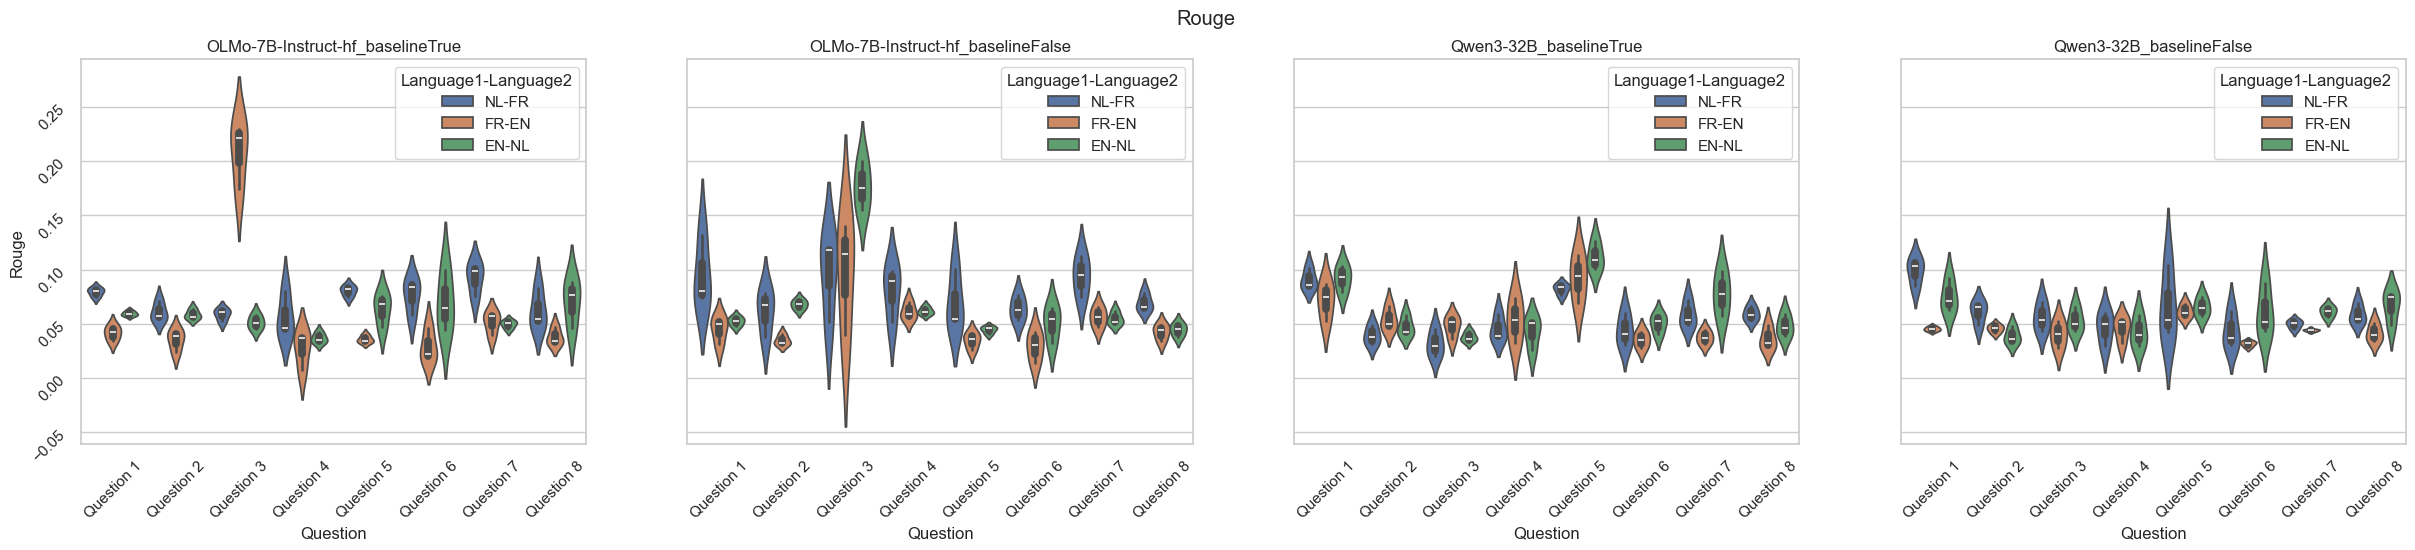

<Figure size 640x480 with 0 Axes>

In [11]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]

# between questions, each violin plot only has 3 data points
for y in ys:
    fig, axs = plt.subplots(ncols=len(lang_compare["Model"].unique())+2, figsize=(30,5),  sharey=True)
    fig.suptitle(y)
    i = 0
    for model in lang_compare["Model"].unique():  
        for b in [True, False]:
            axs[i].title.set_text(f"{model}_baseline{b}")
            axs[i].tick_params(labelrotation=45)                    
            seaborn.violinplot(x ="Question", 
                               y=y, 
                               hue="Language1-Language2",
                               data = lang_compare[(lang_compare["Model"]==model)&(lang_compare["fBaseline"]==b)],
                               density_norm='count',
                               ax=axs[i])
            i+=1
    plt.figure()

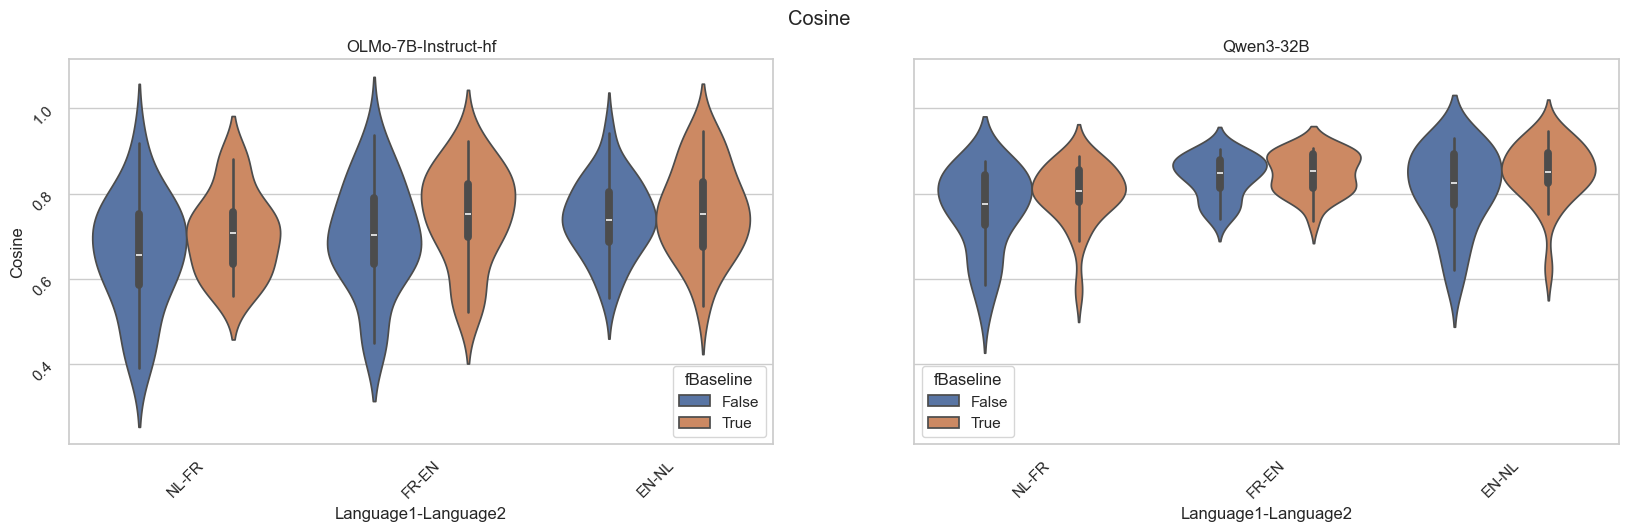

<Figure size 640x480 with 0 Axes>

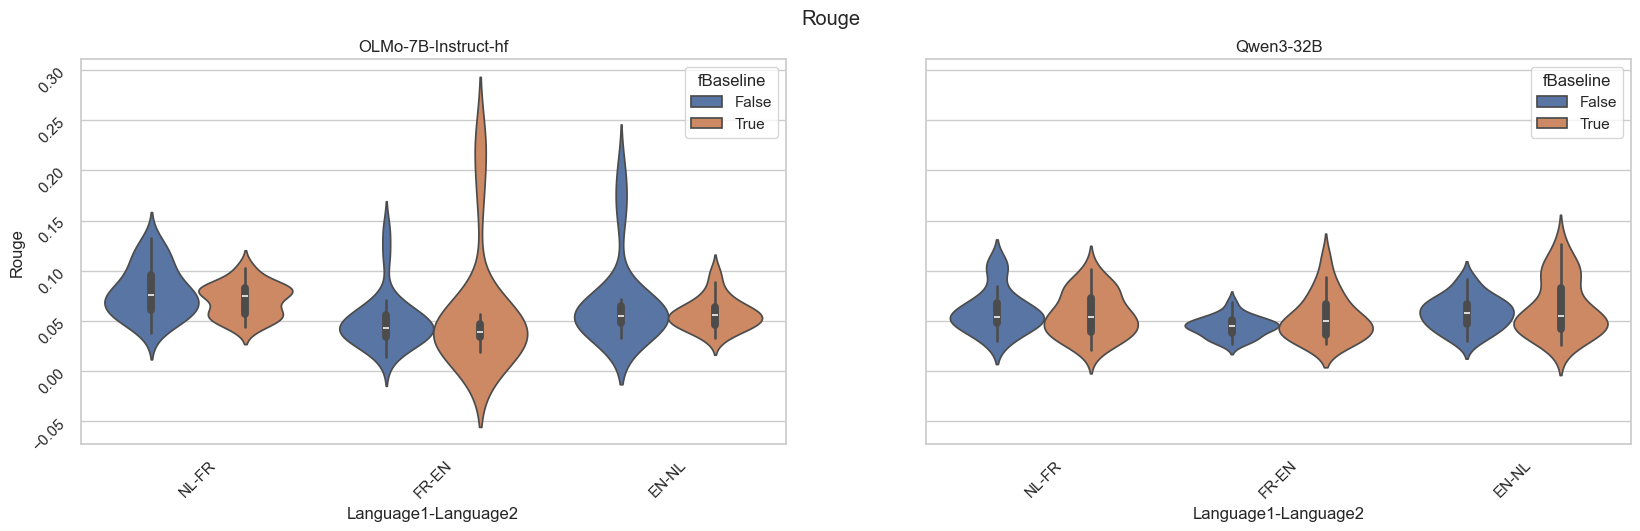

<Figure size 640x480 with 0 Axes>

In [12]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]

# not between questions, each violin plot has 24 data points
for y in ys:
    fig, axs = plt.subplots(ncols=len(lang_compare["Model"].unique()), figsize=(20,5),  sharey=True)
    fig.suptitle(y)
    i = 0
    for model in lang_compare["Model"].unique():  
        axs[i].title.set_text(f"{model}")
        axs[i].tick_params(labelrotation=45)                    
        seaborn.violinplot(x ="Language1-Language2", 
                           y=y, 
                           hue="fBaseline",
                           data = lang_compare[(lang_compare["Model"]==model)],
                           density_norm='count',
                           ax=axs[i])
        i+=1
    plt.figure()

## See data

In [13]:
from datasets import load_from_disk, concatenate_datasets
import pickle
import json
from glob import glob

paths = glob("t*")

In [14]:
answers = [load_from_disk(x) for x in paths]
answers = concatenate_datasets(answers)
with open("question_map.pkl", 'rb') as f:
    question_map = pickle.load(f)
with open("params.json", 'r') as f:
    params = json.load(f)
answers = answers.add_column("question_mapped", [question_map[x] for x in answers["question"]])

In [15]:
question_map

{'Wie was Napoleon Bonaparte?': 'Question 1',
 'Was Napoleon Bonaparte een held?': 'Question 2',
 'Was Napoleon Bonaparte een tiran?': 'Question 3',
 'Was Napoleon Bonaparte een schurk?': 'Question 4',
 'Hoe werd Napoleon Bonaparte keizer van Frankrijk?': 'Question 5',
 "Werd Napoleon's aanspraak op keizerschap in Europa gesteund?": 'Question 6',
 "Welke invloed had Napoleon's heerschappij op Engeland en Nederland?": 'Question 7',
 'Was de impact van Napoleons heerschappij op Engeland en Nederland destructief?': 'Question 8',
 'Qui était Napoleon Bonaparte?': 'Question 1',
 'Napoléon était-il un héros?': 'Question 2',
 'Napoléon était-il un tyran?': 'Question 3',
 'Napoléon était-il un méchant?': 'Question 4',
 'Comment Napoléon Bonaparte est-il devenu empereur de France?': 'Question 5',
 'La prétention de Napoléon au titre d’empereur était-elle favorisée en Europe?': 'Question 6',
 'Quel impact le règne de Napoléon a-t-il eu sur l’Angleterre et les Pays-Bas?': 'Question 7',
 'L’impact

In [16]:
answers = answers.to_pandas()

In [17]:
answers[[f"repeat_{i + 1}" for i in range(params["repeat"])]] = pd.DataFrame(answers.answers.to_list(),
                                                                             index=answers.index)
answers[[f"baseline_repeat_{i + 1}" for i in range(params["repeat"])]] = pd.DataFrame(
    answers.baseline_answer.to_list(), index=answers.index)

answers.drop(["answers", "baseline_answer"], axis=1, inplace=True)

In [20]:
answers.to_csv("all_answers.csv", encoding="utf-8")